# Упражнение № 1 Статические одномерные данные

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

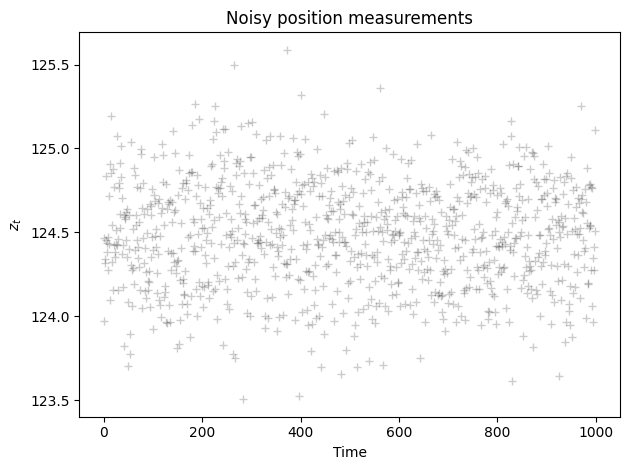

In [4]:
mu = 124.5 # Actual position
R = 0.1    # Actual standard deviation of actual measurements (R)

# Generate measurements
n_measurements = 1000 # Change the number of points to see how the convergence changes
Z = np.random.normal(mu, np.sqrt(R), size=n_measurements)

plt.plot(Z,'k+',label='measurements $z_t$',alpha=0.2)
plt.title('Noisy position measurements')
plt.xlabel('Time')
plt.ylabel('$z_t$')
plt.tight_layout();

Выберем значение для оценочной дисперсии Q > R

In [5]:
# Estimated covariances
Q_est = 1e-2 # cov шума процесса
R_est = 2e-4 # cov шума измерений

In [6]:
def kalman_1d(x, P, measurement, R_est, Q_est):

    # Prediction
    x_pred = x
    P_pred = P + Q_est

    # Update
    K = P_pred / (P_pred + R_est)
    x_est = x_pred + K * (measurement - x_pred)
    P_est = (1 - K) * P_pred

    return x_est, P_est

In [11]:
(0.04+1e-2) / (0.04+1e-2 + 2e-4)

0.9960159362549801

In [7]:
# initial guesses
x = 123 # Use an integer (imagine the initial guess is determined with a meter stick)
P = 0.04 # error covariance P

KF_estimate=[] # To store the position estimate at each time point
KF_error=[] # To store estimated error at each time point
for z in Z:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

In [8]:
def plot_1d_comparison(measurements_made, estimate, true_value, axis):
    axis.plot(measurements_made,'k+',label='measurements',alpha=0.3)
    axis.plot(estimate,'-',label='KF estimate')
    if not isinstance(true_value, (list, tuple, np.ndarray)):
        # plot line for a constant value
        axis.axhline(true_value,color='r',label='true value', alpha=0.5)
    else:
        # for a list, tuple or array, plot the points
        axis.plot(true_value,color='r',label='true value', alpha=0.5)
    axis.legend(loc = 'lower right')
    axis.set_title('Estimated position vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$x_t$')

def plot_1d_error(estimated_error, lower_limit, upper_limit, axis):
    # lower_limit and upper_limit are the lower and upper limits of the vertical axis
    axis.plot(estimated_error, label='KF estimate for $P$')
    axis.legend(loc = 'upper right')
    axis.set_title('Estimated error vs. time step')
    axis.set_xlabel('Time')
    axis.set_ylabel('$P_t$')
    plt.setp(axis,'ylim',[lower_limit, upper_limit])

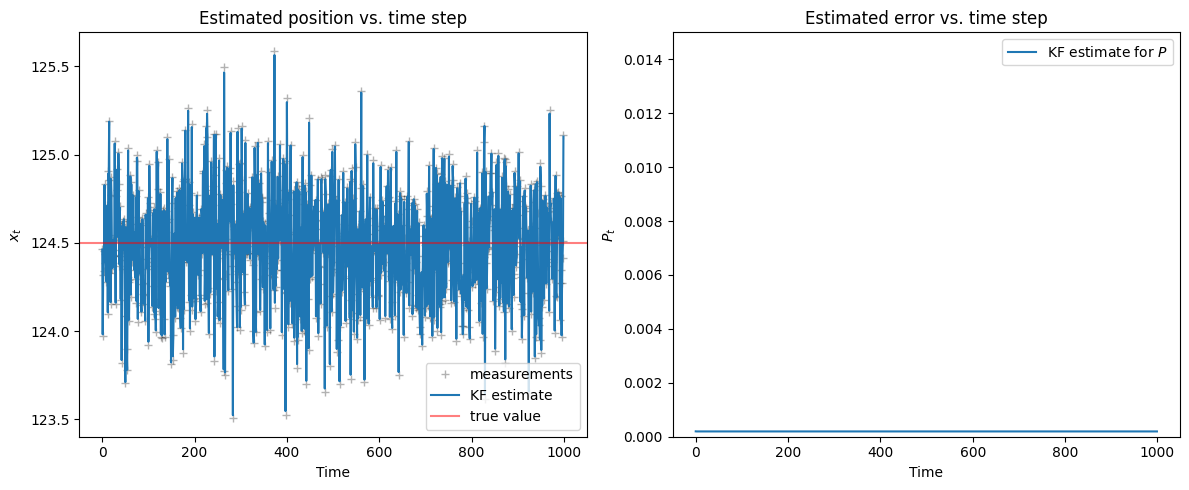

In [9]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Z, KF_estimate, mu, axes[0])
plot_1d_error(KF_error, 0, 0.015, axes[1])
plt.tight_layout();

## Выводы

Дисперсия Q_est применяется для вычисления P_pred, которая, в свою очередь, используется для определения коэффициента доверия K. В случае, когда Q_est превышает R_est, значение K стремится к единице. В процессе вычисления x_est к текущему значению x добавляется полная разница, что приводит к максимальному размаху дисперсии. Поскольку основное внимание сосредоточено на x_est, P_est стремится к нулю, что свидетельствует о сходимости оценки KF.

# Упражнение №2 Динамические одномерные данные

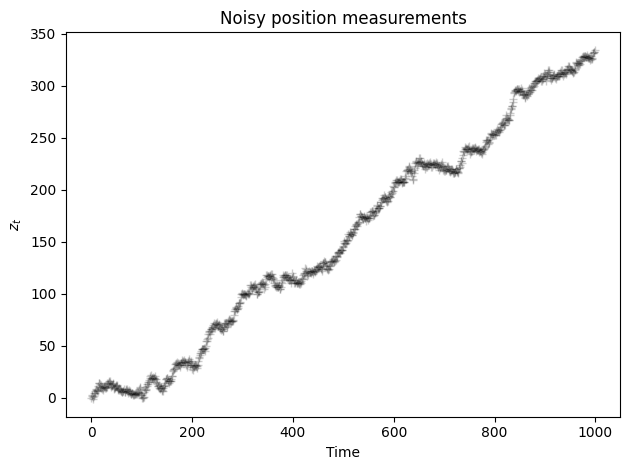

In [39]:
# initial parameters
v0 = 0.3
x0 = 0.0
R = 4.0

# generate noisy measurements
n_measurements = 1000
Zv = np.zeros(n_measurements) # velocity measurements
Zx = np.zeros(n_measurements) # position measurements
for t in range(0, n_measurements-1):
    Zv[t] = np.random.normal(v0, np.sqrt(R))
    Zx[t+1] = Zx[t] + Zv[t] * 1 # delta_t = 1

# generate true positions
Xt = np.zeros(n_measurements)
for t in range(0, n_measurements):
    Xt[t]= x0 + v0*t

plt.plot(Zx,'k+',label='measurements $z_t$',alpha=0.2)
plt.title('Noisy position measurements')
plt.xlabel('Time')
plt.ylabel('$z_t$')
plt.tight_layout();

1. Измерения, оценка KF и истинное значение все близки.

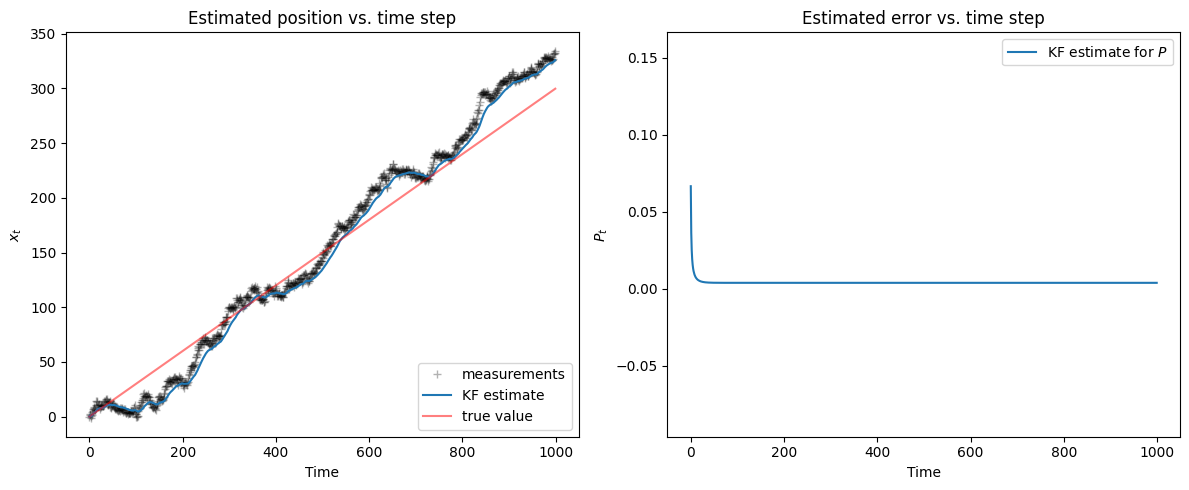

In [134]:
# initial guesses and estimates
x = 0
P = 0.4
Q_est = 0.0002 # cov шума процесса
R_est = 0.08 # cov шума измерений
KF_estimate = [] # To store the position estimate at each time point
KF_error = [] # To store estimated error at each time point

# Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout();

Маленький Q -> сильно верит в постоянную скорость.
Умеренно большой R -> не слишком верит зашумлённым измерениям -> оценка находится достаточно близки к истинной прямой.

2. Измерения, оценка KF и истинное значение все заметно отличаются.

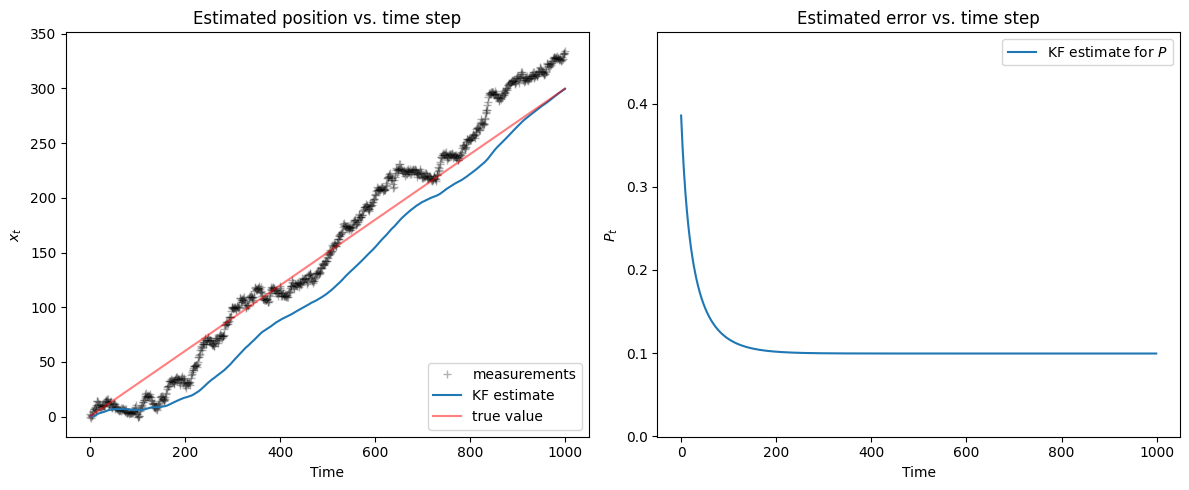

In [133]:
# initial guesses and estimates
x = 0
P = 0.4
Q_est = 0.001 # cov шума процесса
R_est = 10 # cov шума измерений
KF_estimate = [] # To store the position estimate at each time point
KF_error = [] # To store estimated error at each time point

# Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout();

Большой Q -> фильтр считает, что скорость может сильно меняться.
Средний/большой R → не очень доверяет измерениям -> оценка начинает свободно дрейфовать -> все три линии расходятся.

3. Измерения близки к истинному значению, но оценка KF отличается.

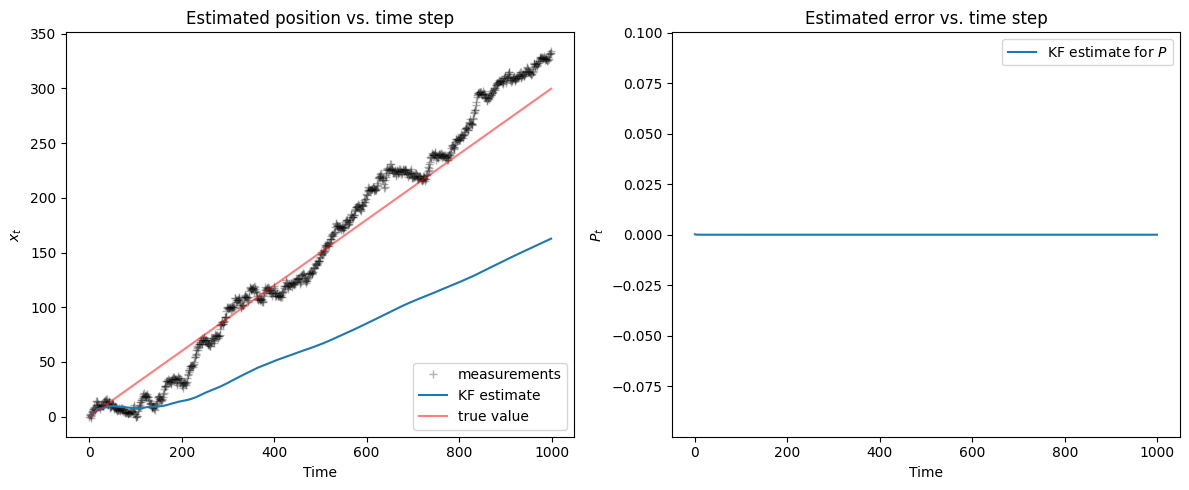

In [135]:
# initial guesses and estimates
x = 0
P = 0.4
Q_est = 1e-10 # cov шума процесса
R_est = 2e-4 # cov шума измерений
KF_estimate = [] # To store the position estimate at each time point
KF_error = [] # To store estimated error at each time point

# Kalman filter
for z in Zx:
    x, P = kalman_1d(x, P, z, R_est, Q_est)
    KF_estimate.append(x)
    KF_error.append(P)

fig, axes = plt.subplots(1,2, figsize=(12, 5))
plot_1d_comparison(Zx, KF_estimate, Xt, axes[0])
plot_1d_error(KF_error, min(KF_error)-0.1, max(KF_error)+0.1, axes[1])
plt.tight_layout();

Очень маленький Q -> почти не допускает изменения скорости.
Очень маленький R -> считает измерения сверхточными -> фильтр «застревает» на начальной траектории и почти не корректируется -> оценка уходит в сторону, хотя измерения остаются близко к истине.

# Упражнение №3 Динамические двумерные данные

In [138]:
import cv2

In [155]:
kalman = cv2.KalmanFilter(2,2,0) # 4 states, 2 measurements, 0 control vector

q = 1 # the variance in the model
r = 20 # the variance in the measurement

kalman.measurementMatrix = np.array([[1,0],
                                     [0,1]],np.float32) #  H
kalman.transitionMatrix = np.array([[1,0],
                                    [0,1]],np.float32) # A
kalman.processNoiseCov = np.array([[1,0],
                                   [0,1]],np.float32) * q # Q
kalman.measurementNoiseCov = np.array([[1,0],
                                       [0,1]],np.float32) * r # R

KF_estimate_xy = [] # To store the position estimate at each time point

In [156]:
xy_motion = pd.read_csv('https://zenodo.org/records/10951538/files/kf_ts1.csv?download=1',
                        header = None).values.astype('float32')

In [157]:
print(len(xy_motion))
print(xy_motion[0:10]) # Print first 10 items for clarity, but can look at all 205 or plot them

205
[[2.35 1.45]
 [3.55 1.8 ]
 [3.   2.9 ]
 [2.65 4.2 ]
 [2.95 5.15]
 [3.7  5.4 ]
 [4.8  5.55]
 [5.3  5.25]
 [5.7  5.25]
 [5.8  5.85]]


In [158]:
for i in xy_motion:
    print(i)
    pred = kalman.predict()  # predicts new state using the model
    kalman.correct(i)      # updates estimated state with the measurement
    KF_estimate_xy.append(((pred[0]),(pred[1]))) # store the estimated position

[2.35 1.45]
[3.55 1.8 ]
[3.  2.9]
[2.65 4.2 ]
[2.95 5.15]
[3.7 5.4]
[4.8  5.55]
[5.3  5.25]
[5.7  5.25]
[5.8  5.85]
[5.8 6.9]
[5.8 7.9]
[5.4 8.7]
[4.75 9.9 ]
[ 4.  10.6]
[ 4.05 11.9 ]
[ 4.5 12.2]
[ 5.4 12.7]
[ 6.05 12.75]
[ 6.8 12.4]
[ 8.  12.6]
[ 8.85 12.75]
[ 9.7 12.9]
[ 9.75 13.85]
[ 9.75 15.2 ]
[ 9.9  16.75]
[ 9.9  18.05]
[10.   19.25]
[10.   20.25]
[10.   21.15]
[10.   21.65]
[10.   22.55]
[10.05 23.8 ]
[10.65 24.5 ]
[11.15 24.55]
[11.6  24.85]
[12.1 25.4]
[13.3  25.85]
[14.25 26.15]
[15.45 26.45]
[16.7 26.5]
[17.7  26.55]
[19.2  26.55]
[19.95 26.6 ]
[20.45 26.45]
[20.2  25.85]
[20.2 25.2]
[20.35 24.7 ]
[20.75 23.95]
[21.4 23.3]
[21.8  22.95]
[22.25 22.6 ]
[22.35 22.15]
[22.2  21.75]
[21.4 21.5]
[20.35 21.45]
[19.6 21.3]
[18.9 21. ]
[18.4  20.55]
[18.4 19.9]
[19.3 19.3]
[19.85 19.3 ]
[20.7 19.3]
[21.15 19.3 ]
[21.7 19.3]
[22.55 19.3 ]
[23.55 19.3 ]
[24.2 19.3]
[24.9 19.3]
[25.7 19.3]
[26.05 19.8 ]
[26.45 20.45]
[27. 21.]
[27.6 21.4]
[28.4  21.55]
[29.25 21.55]
[30.05 21.55]
[30.25

In [160]:
# Quick check: estimate has same length as measurement data
print(len(KF_estimate_xy))

205


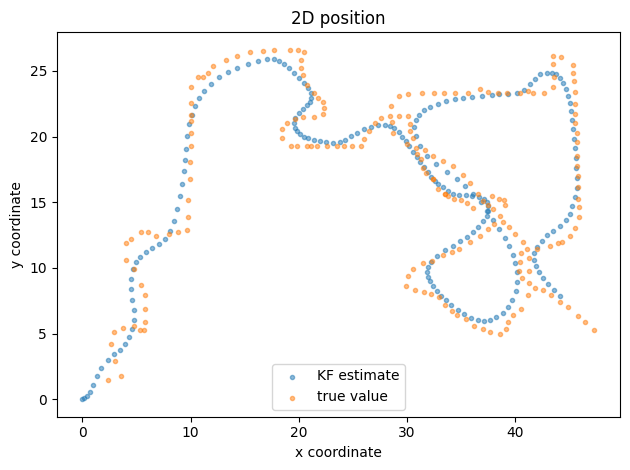

In [161]:
x_est, y_est = zip(*KF_estimate_xy)
x_true, y_true = zip(*xy_motion)
plt.scatter(x_est, y_est, marker= '.', label = 'KF estimate', alpha = 0.5)
plt.scatter(x_true, y_true,marker= '.', label = 'true value', alpha = 0.5)
plt.legend(loc = 'lower center')
plt.title('2D position')
plt.xlabel('x coordinate')
plt.ylabel('y coordinate')
plt.tight_layout();

Траектория Kalman-фильтра будет гораздо более шумной, чем в модели PV. Фильтр почти не сглаживает движение, он в доверяет последнему измерению.